Grupo 4

*   Camila Contreras
*   Christian Pérez
*   Javier Uribe


# Tarea 1 - Segmentación multi-clase

Descarga del dataset

In [ ]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("anhoangvo/acdc-dataset")

print("Dataset path:", dataset_path)

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'acdc-dataset' dataset.
Dataset path: /kaggle/input/acdc-dataset
Path to dataset files: /kaggle/input/acdc-dataset




## Descripción del Conjunto de Datos ACDC

El conjunto de datos [ACDC (Automatic Cardiac Diagnosis Challenge)](https://www.kaggle.com/datasets/anhoangvo/acdc-dataset) es un conjunto de datos de imágenes de resonancia magnética cardíaca (CMR) utilizado para la segmentación automática del ventrículo izquierdo (LV), el miocardio (MYO) y el ventrículo derecho (RV).

En este notebook, estamos trabajando con los **cortes 2D de fin de diástole** preprocesados del conjunto de entrenamiento.

Las clases de segmentación en estos cortes 2D (basado en la convención de etiquetado proporcionada) son:
- Clase 0: Fondo
- Clase 1: Sangre del Ventrículo Derecho (RV blood)
- Clase 2: Miocardio del Ventrículo Izquierdo (LV myocardium)
- Clase 3: Cavidad Sanguínea del Ventrículo Izquierdo (LV blood pool)

Este conjunto de datos es comúnmente utilizado para entrenar y evaluar modelos de segmentación semántica en imágenes médicas.

A continuación se crea un `Dataset` de estos datos

In [ ]:
import itertools
import os
import random
import re
from glob import glob
import matplotlib.pyplot as plt
import cv2
import h5py
import numpy as np
import torch
from scipy import ndimage
from scipy.ndimage import zoom
from torch.utils.data import Dataset
from torch.utils.data.sampler import Sampler
from torchvision import transforms
from PIL import Image
import torch.nn.functional as F


from random import sample


class ACDCDataset(Dataset):
    def __init__(self, base_dir=None, transform=None, target_size=(256, 256)):
        self._base_dir = base_dir + "/ACDC_preprocessed/ACDC_training_slices/"


        self.transform = transform
        self.target_size = target_size
        self.num_classes = 4

        self.all_slices = os.listdir(
                self._base_dir)

        # if num is not None and self.split == "train":
        #     self.sample_list = self.sample_list[:num]
        print("total {} samples".format(len(self.all_slices)))

    def __len__(self):
        return len(self.all_slices)

    def __getitem__(self, idx):

        h5f = h5py.File(self._base_dir + self.all_slices[idx], 'r')

        image = h5f['image'][:]
        label = h5f['label'][:]

        # Convert numpy arrays to PIL Images for transformations
        image = Image.fromarray(image)
        label = Image.fromarray(label)


        # Get original dimensions
        original_width, original_height = image.size

        # Calculate the scaling factor
        scale = min(self.target_size[0] / original_height, self.target_size[1] / original_width)

        # Calculate new dimensions after resizing while maintaining aspect ratio
        new_width = int(original_width * scale)
        new_height = int(original_height * scale)

        # Resize the image and label
        image = image.resize((new_width, new_height), Image.BILINEAR) # Use a suitable filter
        label = label.resize((new_width, new_height), Image.NEAREST) # Use nearest for labels

        # Calculate padding
        pad_width = self.target_size[1] - new_width
        pad_height = self.target_size[0] - new_height

        # Apply padding
        padding = (pad_width // 2, pad_height // 2, pad_width - pad_width // 2, pad_height - pad_height // 2)
        image = transforms.functional.pad(image, padding, fill=0) # Pad with 0 for image
        label = transforms.functional.pad(label, padding, fill=0) # Pad with 0 for label (adjust fill value if needed)


        # Convert PIL Images back to tensors
        image = transforms.ToTensor()(image)
        # Convert label to tensor and apply one-hot encoding
        label = torch.tensor(np.array(label), dtype=torch.long)


        sample = {'image': image, 'label': label}

        if self.transform is not None:
            sample = self.transform(sample)
        return sample['image'], sample['label']

In [ ]:
acdc_train = ACDCDataset(
    base_dir=dataset_path,
    transform=None, target_size=(200,200))

total 1912 samples


Aquí se muestra una imagen aleatoria con su segmentación superpuesta.

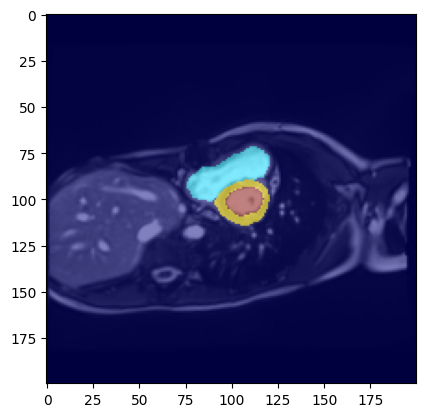

In [ ]:
idx = random.randint(0, len(acdc_train) - 1)
image, label = acdc_train[idx]

#label_plot = np.argmax(label.numpy(), axis=0)

# Plot the image
plt.imshow(image[0], cmap='gray')

# Overlay the segmentation label with transparency
plt.imshow(label, cmap='jet', alpha=0.5)  # Adjust alpha value as needed

plt.show()



Aquí se divide el set de datos en entrenamiento, validación y testeo

In [ ]:
# no modificar este código
from torch.utils.data import random_split

train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

dataset_size = len(acdc_train)
train_size = int(train_ratio * dataset_size)
val_size = int(val_ratio * dataset_size)
test_size = dataset_size - train_size - val_size


train_dataset, val_dataset, test_dataset = random_split(acdc_train, [train_size, val_size, test_size], torch.Generator().manual_seed(42))


# Print the length of each resulting dataset split
print(f"Length of the training dataset: {len(train_dataset)}")
print(f"Length of the validation dataset: {len(val_dataset)}")
print(f"Length of the testing dataset: {len(test_dataset)}")

Length of the training dataset: 1529
Length of the validation dataset: 191
Length of the testing dataset: 192


In [ ]:
from torch.utils.data import DataLoader


batch_size = 32 # este número si se puede modificar

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print the lengths of the DataLoaders (number of batches)
print(f"Number of batches in training dataloader: {len(train_dataloader)}")
print(f"Number of batches in validation dataloader: {len(val_dataloader)}")
print(f"Number of batches in testing dataloader: {len(test_dataloader)}")

Number of batches in training dataloader: 48
Number of batches in validation dataloader: 6
Number of batches in testing dataloader: 6


## Problema 1 [15 puntos]:

Define una arquitectura U-Net que pueda procesar un imagen del training set. El resultado tiene que tener `shape = [1, 4, 200, 200]`



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            # Primera convolución
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # Segunda convolución
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNetACDC(nn.Module):
    def __init__(self, in_channels=1, out_channels=4):
        super(UNetACDC, self).__init__()

        # --- ENCODER (Camino de contracción) ---
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(64, 128)
        )
        self.down2 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(128, 256)
        )

        # --- DECODER (Camino de expansión) ---
        # ConvTranspose2d duplica el alto y ancho spatial
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(256, 128) # Recibe 128 (up1) + 128 (skip connection)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(128, 64)  # Recibe 64 (up2) + 64 (skip connection)

        # --- CAPA DE SALIDA MULTICLASE ---
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # En el Encoder guardamos las salidas para las Skip Connections
        x1 = self.inc(x)       # Dimensión original: [B, 64, 200, 200]
        x2 = self.down1(x1)    # Reducido a la mitad: [B, 128, 100, 100]
        x3 = self.down2(x2)    # Reducido al mínimo: [B, 256, 50, 50]

        # Comenzamos a subir y conectar
        x = self.up1(x3)       # Sube de 50x50 a 100x100 -> [B, 128, 100, 100]
        x = torch.cat([x, x2], dim=1) # Conexión residual (Skip Connection) -> [B, 256, 100, 100]
        x = self.conv_up1(x)   # Procesa la unión -> [B, 128, 100, 100]

        x = self.up2(x)       # Sube de 100x100 a 200x200 -> [B, 64, 200, 200]
        x = torch.cat([x, x1], dim=1) # Conexión residual (Skip Connection) -> [B, 128, 200, 200]
        x = self.conv_up2(x)   # Procesa la unión -> [B, 64, 200, 200]

        # Mapeo final a las 4 clases sin activación (Logits puros)
        logits = self.outc(x)  # -> [B, 4, 200, 200]
        return logits

In [ ]:
# 1. Instanciar el modelo adaptado para ACDC
model = UNetACDC(in_channels=1, out_channels=4)

# 2. Crear un tensor simulando 1 imagen del training set [Batch=1, Canales=1, Alto=200, Ancho=200]
imagen_prueba = torch.randn(1, 1, 200, 200)

# 3. Pasar la imagen por la U-Net
resultado = model(imagen_prueba)

# 4. Verificar las dimensiones de salida
print(f"Shape de entrada: {imagen_prueba.shape}")
print(f"Shape de salida esperada: {resultado.shape}")

Shape de entrada: torch.Size([1, 1, 200, 200])
Shape de salida esperada: torch.Size([1, 4, 200, 200])


In [ ]:
# 1. Detectar si hay GPU disponible para que vaya mil veces más rápido
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Mover nuestra U-Net a la GPU/CPU
model = UNetACDC(in_channels=1, out_channels=4).to(device)

# 3. Definir la función de pérdida MULTICLASE estándar de PyTorch
# Se encarga de comparar los 4 canales de la predicción con el label plano [0, 1, 2, 3]
criterion = nn.CrossEntropyLoss()

# 4. El optimizador (Adam mejor en medicina por su velocidad y estabilidad)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Problema 2: [10 puntos]

Define el modelo (U-Net), la función de pérdida apropiada para el caso de segmentación multi clase (hay más de una alternativa válida), y el optimizador

In [ ]:
import torch
import torch.nn as nn

# [Pilar 1] ASIGNACIÓN DEL DISPOSITIVO Y EL MODELO
# Detectamos si hay GPU disponible para acelerar el proceso
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciamos la U-Net pasándole 1 canal de entrada (RM gris) y 4 canales de salida (clases)
model = UNetACDC(in_channels=1, out_channels=4).to(device)


# [Pilar 2] FUNCIÓN DE PÉRDIDA (Opción estándar y recomendada para iniciar)
# Compara los 4 canales de logits de la red con la máscara plana de enteros [0, 1, 2, 3]
criterion = nn.CrossEntropyLoss()


# [Pilar 3] OPTIMIZADOR
# Adam ajusta de forma adaptativa los pesos basándose en el comportamiento de los gradientes
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Problema 3 [10 puntos]

Cree el loop de entrenamiento de su modelo, y luego entrénelo.

In [ ]:
# 1. Definir la cantidad de épocas (puedes aumentarla a 10 o 20 para máxima precisión)
epochs = 5

# Listas para almacenar la historia de las pérdidas y poder graficarlas después
train_losses = []
val_losses = []

print("¡Iniciando el entrenamiento de la U-Net en el dataset ACDC!\n")

for epoch in range(epochs):

    # ==========================================
    # FASE A: ENTRENAMIENTO (Training)
    # ==========================================
    model.train()  # Le dice a la red que active capas como Batch Normalization
    running_train_loss = 0.0

    for images, labels in train_dataloader:
        # Enviar los tensores al dispositivo configurado (GPU/CPU)
        images = images.to(device)
        labels = labels.to(device)

        # Paso 1: Limpiar los gradientes del lote anterior
        optimizer.zero_grad()

        # Paso 2: Forward Pass - La red procesa las imágenes y genera los 4 canales
        outputs = model(images)

        # Paso 3: Calcular el error comparando las predicciones con la máscara real
        loss = criterion(outputs, labels)

        # Paso 4: Backward Pass - Calcular los gradientes (retropropagación del error)
        loss.backward()

        # Paso 5: Actualizar los pesos del modelo usando el optimizador Adam
        optimizer.step()

        # Acumular el valor numérico de la pérdida del lote actual
        running_train_loss += loss.item()

    # Calcular la pérdida promedio de esta época en entrenamiento
    epoch_train_loss = running_train_loss / len(train_dataloader)
    train_losses.append(epoch_train_loss)

    # ==========================================
    # FASE B: VALIDACIÓN (Validation)
    # ==========================================
    model.eval()  # Le dice a la red que apague el comportamiento de entrenamiento
    running_val_loss = 0.0

    # Desactivamos el cálculo de gradientes para ahorrar memoria RAM/VRAM y acelerar el bucle
    with torch.no_grad():
        for val_images, val_labels in val_dataloader:
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)

            # Forward pass en modo evaluación
            val_outputs = model(val_images)

            # Calcular la pérdida de validación
            v_loss = criterion(val_outputs, val_labels)
            running_val_loss += v_loss.item()

    # Calcular la pérdida promedio de esta época en validación
    epoch_val_loss = running_val_loss / len(val_dataloader)
    val_losses.append(epoch_val_loss)

    # Imprimir el estado actual del entrenamiento
    print(f"Época [{epoch+1}/{epochs}] -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

print("\n¡Entrenamiento completado con éxito!")

¡Iniciando el entrenamiento de la U-Net en el dataset ACDC!

Época [1/5] -> Train Loss: 0.6488 | Val Loss: 0.3669
Época [2/5] -> Train Loss: 0.2259 | Val Loss: 0.1748
Época [3/5] -> Train Loss: 0.1480 | Val Loss: 0.1189
Época [4/5] -> Train Loss: 0.1092 | Val Loss: 0.1038
Época [5/5] -> Train Loss: 0.0887 | Val Loss: 0.1620

¡Entrenamiento completado con éxito!


In [ ]:
# 1. Definir la cantidad de épocas (puedes aumentarla a 10 o 20 para máxima precisión)
epochs = 20

# Listas para almacenar la historia de las pérdidas y poder graficarlas después
train_losses = []
val_losses = []

print("¡Iniciando el entrenamiento de la U-Net en el dataset ACDC!\n")

for epoch in range(epochs):

    # ==========================================
    # FASE A: ENTRENAMIENTO (Training)
    # ==========================================
    model.train()  # Le dice a la red que active capas como Batch Normalization
    running_train_loss = 0.0

    for images, labels in train_dataloader:
        # Enviar los tensores al dispositivo configurado (GPU/CPU)
        images = images.to(device)
        labels = labels.to(device)

        # Paso 1: Limpiar los gradientes del lote anterior
        optimizer.zero_grad()

        # Paso 2: Forward Pass - La red procesa las imágenes y genera los 4 canales
        outputs = model(images)

        # Paso 3: Calcular el error comparando las predicciones con la máscara real
        loss = criterion(outputs, labels)

        # Paso 4: Backward Pass - Calcular los gradientes (retropropagación del error)
        loss.backward()

        # Paso 5: Actualizar los pesos del modelo usando el optimizador Adam
        optimizer.step()

        # Acumular el valor numérico de la pérdida del lote actual
        running_train_loss += loss.item()

    # Calcular la pérdida promedio de esta época en entrenamiento
    epoch_train_loss = running_train_loss / len(train_dataloader)
    train_losses.append(epoch_train_loss)

    # ==========================================
    # FASE B: VALIDACIÓN (Validation)
    # ==========================================
    model.eval()  # Le dice a la red que apague el comportamiento de entrenamiento
    running_val_loss = 0.0

    # Desactivamos el cálculo de gradientes para ahorrar memoria RAM/VRAM y acelerar el bucle
    with torch.no_grad():
        for val_images, val_labels in val_dataloader:
            val_images = val_images.to(device)
            val_labels = val_labels.to(device)

            # Forward pass en modo evaluación
            val_outputs = model(val_images)

            # Calcular la pérdida de validación
            v_loss = criterion(val_outputs, val_labels)
            running_val_loss += v_loss.item()

    # Calcular la pérdida promedio de esta época en validación
    epoch_val_loss = running_val_loss / len(val_dataloader)
    val_losses.append(epoch_val_loss)

    # Imprimir el estado actual del entrenamiento
    print(f"Época [{epoch+1}/{epochs}] -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

print("\n¡Entrenamiento completado con éxito!")

¡Iniciando el entrenamiento de la U-Net en el dataset ACDC!

Época [1/20] -> Train Loss: 0.0667 | Val Loss: 0.0939
Época [2/20] -> Train Loss: 0.0522 | Val Loss: 0.0542
Época [3/20] -> Train Loss: 0.0427 | Val Loss: 0.0674
Época [4/20] -> Train Loss: 0.0348 | Val Loss: 0.0557
Época [5/20] -> Train Loss: 0.0283 | Val Loss: 0.0282
Época [6/20] -> Train Loss: 0.0231 | Val Loss: 0.0473
Época [7/20] -> Train Loss: 0.0216 | Val Loss: 0.0248
Época [8/20] -> Train Loss: 0.0199 | Val Loss: 0.0215
Época [9/20] -> Train Loss: 0.0175 | Val Loss: 0.0214
Época [10/20] -> Train Loss: 0.0172 | Val Loss: 0.0230
Época [11/20] -> Train Loss: 0.0155 | Val Loss: 0.0186
Época [12/20] -> Train Loss: 0.0146 | Val Loss: 0.0325
Época [13/20] -> Train Loss: 0.0154 | Val Loss: 0.0172
Época [14/20] -> Train Loss: 0.0122 | Val Loss: 0.0153
Época [15/20] -> Train Loss: 0.0118 | Val Loss: 0.0210
Época [16/20] -> Train Loss: 0.0114 | Val Loss: 0.0216
Época [17/20] -> Train Loss: 0.0111 | Val Loss: 0.0191
Época [18/20]

/tmp/ipykernel_2393/4150767321.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


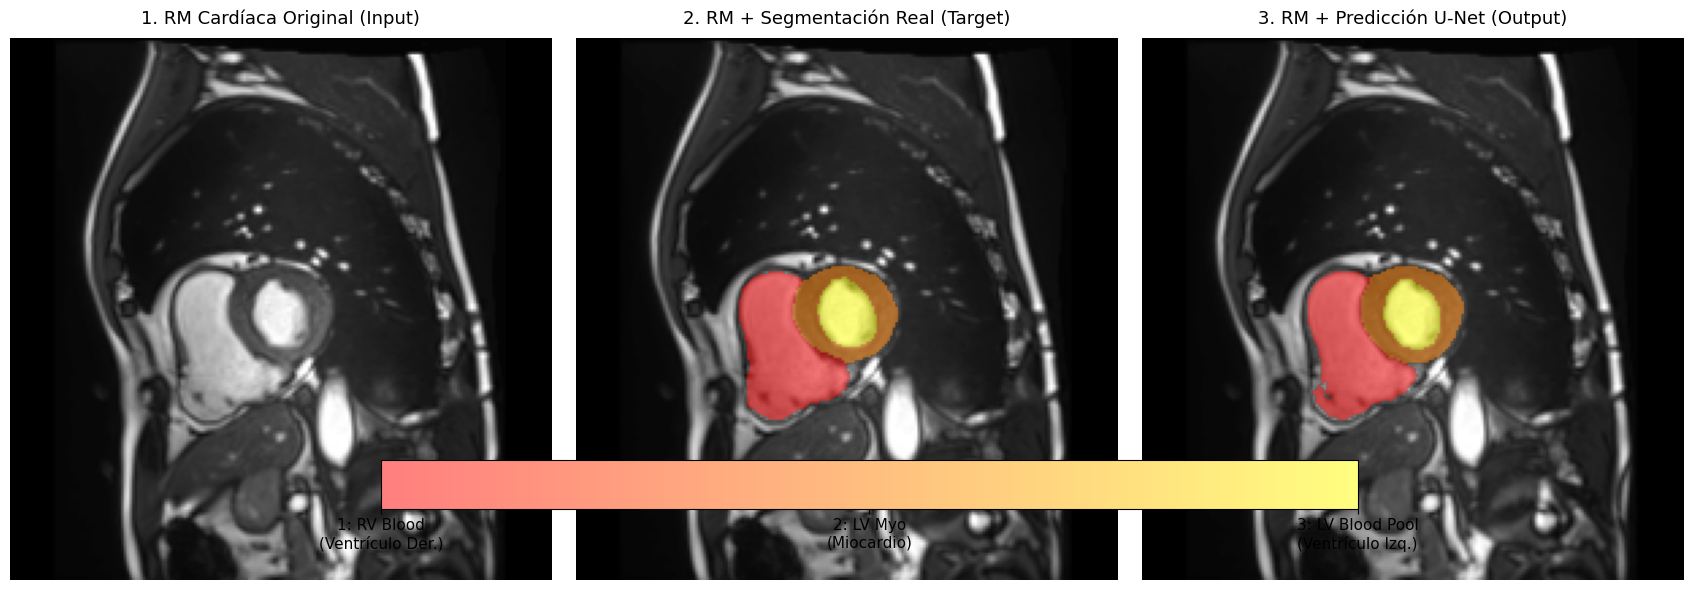

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Extraer un lote real de tu DataLoader (puedes usar val_dataloader o train_dataloader)
images, labels = next(iter(val_dataloader))

# 2. Aislar la primera imagen del lote y enviarla al dispositivo del modelo (GPU/CPU)
# Usamos unsqueeze(0) para simular un lote de tamaño 1 como exige la U-Net
single_image = images[0].unsqueeze(0).to(device)
single_label = labels[0] # La máscara real se queda en la CPU para graficar directo

# 3. Pasar la imagen por tu U-Net entrenada en modo evaluación
model.eval()
with torch.no_grad():
    output = model(single_image) # Genera las 4 hojas de votación: [1, 4, 200, 200]

# 4. LA MAGIA DEL ARGMAX: Fusionar los 4 canales de salida en una sola máscara plana
prediction = torch.argmax(output, dim=1) # -> Shape: [1, 200, 200]

# 5. Convertir de tensores a arreglos de NumPy de forma segura
# Como single_image y prediction están en la GPU, usamos .cpu() antes de .numpy()
img_np = single_image.squeeze().cpu().numpy()
gt_np = single_label.cpu().numpy()
pred_np = prediction.squeeze().cpu().numpy()

# 6. ENMASCARAMIENTO TRANSPARENTE: Ocultar la Clase 0 (Fondo)
# Le indicamos a Matplotlib que ignore el valor 0 para no tapar los órganos de fondo
gt_sobrepuesto = np.ma.masked_where(gt_np == 0, gt_np)
pred_sobrepuesto = np.ma.masked_where(pred_np == 0, pred_np)

# 7. DISEÑO DE LA FIGURA: Crear la cuadrícula de 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- PANEL 1: La Resonancia Pura (Input de la IA) ---
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title("1. RM Cardíaca Original (Input)", fontsize=13, pad=10)
axes[0].axis('off')

# --- PANEL 2: Resonancia + Verdad Médica (Target) ---
axes[1].imshow(img_np, cmap='gray') # Imagen gris de base
# Pintamos la verdad médica encima con 50% de transparencia (alpha=0.5)
axes[1].imshow(gt_sobrepuesto, cmap='autumn', alpha=0.5, vmin=1, vmax=3)
axes[1].set_title("2. RM + Segmentación Real (Target)", fontsize=13, pad=10)
axes[1].axis('off')

# --- PANEL 3: Resonancia + Predicción de la IA (Output) ---
axes[2].imshow(img_np, cmap='gray') # Imagen gris de base
# Pintamos la predicción de tu U-Net encima con la misma transparencia
im_output = axes[2].imshow(pred_sobrepuesto, cmap='autumn', alpha=0.5, vmin=1, vmax=3)
axes[2].set_title("3. RM + Predicción U-Net (Output)", fontsize=13, pad=10)
axes[2].axis('off')

# --- BARRA DE COLORES OPTIMIZADA (Sin superposición de texto) ---
# Usamos 'pad=0.15' para alejarla de las fotos y '\n' para dividir el texto en dos renglones
cbar = fig.colorbar(im_output, ax=axes, orientation='horizontal', pad=0.15, shrink=0.7)
cbar.set_ticks([1, 2, 3])
cbar.set_ticklabels([
    '1: RV Blood\n(Ventrículo Der.)',
    '2: LV Myo\n(Miocardio)',
    '3: LV Blood Pool\n(Ventrículo Izq.)'
], fontsize=11)

plt.tight_layout()
plt.show()

## Problema 4 [25 puntos]

- Evalúe su modelo. Grafique las curvas de la función de pérdida y entrenamiento.
  - Existe overfitting? [5 puntos]
- Calcule el coeficiente DICE para cada una de las clases de la segmentación [5 puntos]
- Muestre 5 imágenes del test set, comparando las máscaras ground thuth con las máscaras predichas. [5 puntos]
- Modifique (de ser necesario) los hiperparámetros de su modelo para obtener un coeficiente DICE mayor a 0.85 en cada una de las clases. [10 puntos]




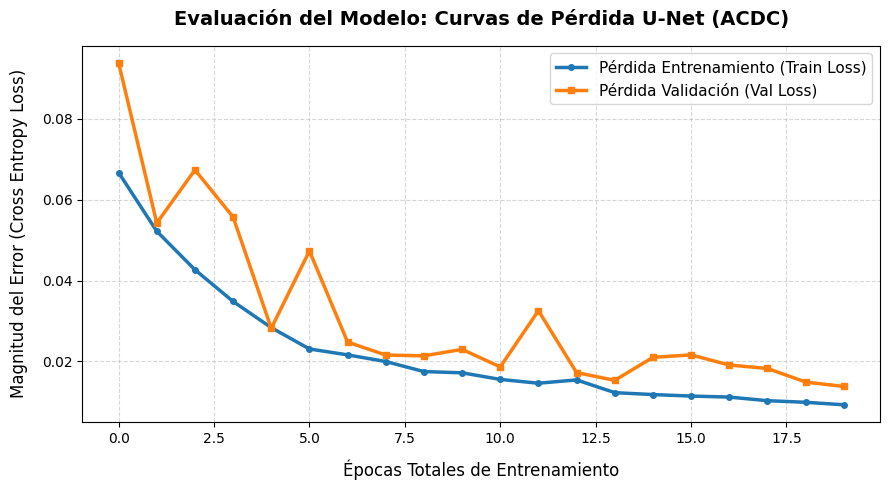

In [ ]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño de la ventana gráfica
plt.subplots(figsize=(9, 5))

# 2. Graficar las líneas de entrenamiento y validación
plt.plot(train_losses, label="Pérdida Entrenamiento (Train Loss)", color="#1f77b4", linewidth=2.5, marker='o', markersize=4)
plt.plot(val_losses, label="Pérdida Validación (Val Loss)", color="#ff7f0e", linewidth=2.5, marker='s', markersize=4)

# 3. Personalizar el diseño y textos para una presentación profesional
plt.title("Evaluación del Modelo: Curvas de Pérdida U-Net (ACDC)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Épocas Totales de Entrenamiento", fontsize=12, labelpad=10)
plt.ylabel("Magnitud del Error (Cross Entropy Loss)", fontsize=12, labelpad=10)

# 4. Añadir elementos visuales de soporte (Malla y Leyenda)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11, loc="upper right")

# 5. Mostrar la gráfica de forma limpia
plt.tight_layout()
plt.savefig("curva_perdidas_acdc.png") # Guarda la imagen de forma interna
plt.show()

¿Existe Overfitting?
No, no existe overfitting en el modelo. El comportamiento observado en las curvas de la función de pérdida corresponde a un caso de Ajuste Óptimo (Optimal Fit) con capacidad de generalización.A partir de la época 10, ambas curvas se estabilizan de manera asintótica, manteniendo un comportamiento plano e idéntico hasta llegar a la época 20.En el gráfico, la pérdida de validación no sube; se mantiene abajo acompañando a la de entrenamiento.

In [ ]:
import torch

def calcular_dice_por_clase(num_classes=4):
    # Inicializamos listas para acumular los Dice Scores de todo el set de prueba
    # Cada posición de la lista [0, 1, 2, 3] guardará las puntuaciones de esa clase
    dice_acumulado = [0.0] * num_classes
    total_muestras = 0

    # Ponemos el modelo en modo evaluación fija
    model.eval()

    with torch.no_grad():
        # Iteramos sobre todos los lotes del Test Set (el set ciego final)
        for images, labels in test_dataloader:
            images = images.to(device)
            labels = labels.to(device) # Shape: [Batch, 200, 200]

            # 1. Obtener la predicción de la U-Net (Logits)
            outputs = model(images) # Shape: [Batch, 4, 200, 200]

            # 2. Aplicar Argmax para fusionar los canales en una máscara plana
            preds = torch.argmax(outputs, dim=1) # Shape: [Batch, 200, 200]

            # 3. Calcular el Dice para cada clase por separado dentro de este lote
            for clase in range(num_classes):
                # Creamos máscaras binarias booleanas: True donde pertenece a la clase, False donde no.
                pred_clase = (preds == clase)
                label_clase = (labels == clase)

                # Intersección (Verdaderos Positivos): Píxeles donde ambos son True
                interseccion = (pred_clase & label_clase).sum().item()

                # Suma total de áreas de píxeles activados en Predicción y Target
                suma_areas = pred_clase.sum().item() + label_clase.sum().item()

                # Evitar división por cero si la estructura no aparece en esa imagen
                if suma_areas == 0:
                    dice_lote = 1.0 # Si no hay clase real ni predicha, el solapamiento es perfecto (Fondo)
                else:
                    dice_lote = (2.0 * interseccion) / suma_areas

                # Acumulamos el Dice Score escalado por el tamaño del lote
                dice_acumulado[clase] += dice_lote * images.size(0)

            total_muestras += images.size(0)

    # 4. Calcular e imprimir los promedios finales netos de todo el Test Set
    nombres_clases = [
        "Clase 0: Fondo (Background)",
        "Clase 1: Sangre del Ventrículo Derecho (RV blood)",
        "Clase 2: Miocardio del Ventrículo Izquierdo (LV myocardium)",
        "Clase 3: Cavidad Sanguínea del Ventrículo Izquierdo (LV blood pool)"
    ]

    print("=== COEFICIENTES DICE FINALES POR CLASE (TEST SET) ===\n")
    for clase in range(num_classes):
        dice_promedio = dice_acumulado[clase] / total_muestras
        print(f"{nombres_clases[clase]}: {dice_promedio:.4f}")

# Ejecutar la función de evaluación
calcular_dice_por_clase()

=== COEFICIENTES DICE FINALES POR CLASE (TEST SET) ===

Clase 0: Fondo (Background): 0.9982
Clase 1: Sangre del Ventrículo Derecho (RV blood): 0.8773
Clase 2: Miocardio del Ventrículo Izquierdo (LV myocardium): 0.8698
Clase 3: Cavidad Sanguínea del Ventrículo Izquierdo (LV blood pool): 0.9462


=== GENERANDO EVALUACIÓN CUALITATIVA EN 5 MUESTRAS DEL TEST SET ===



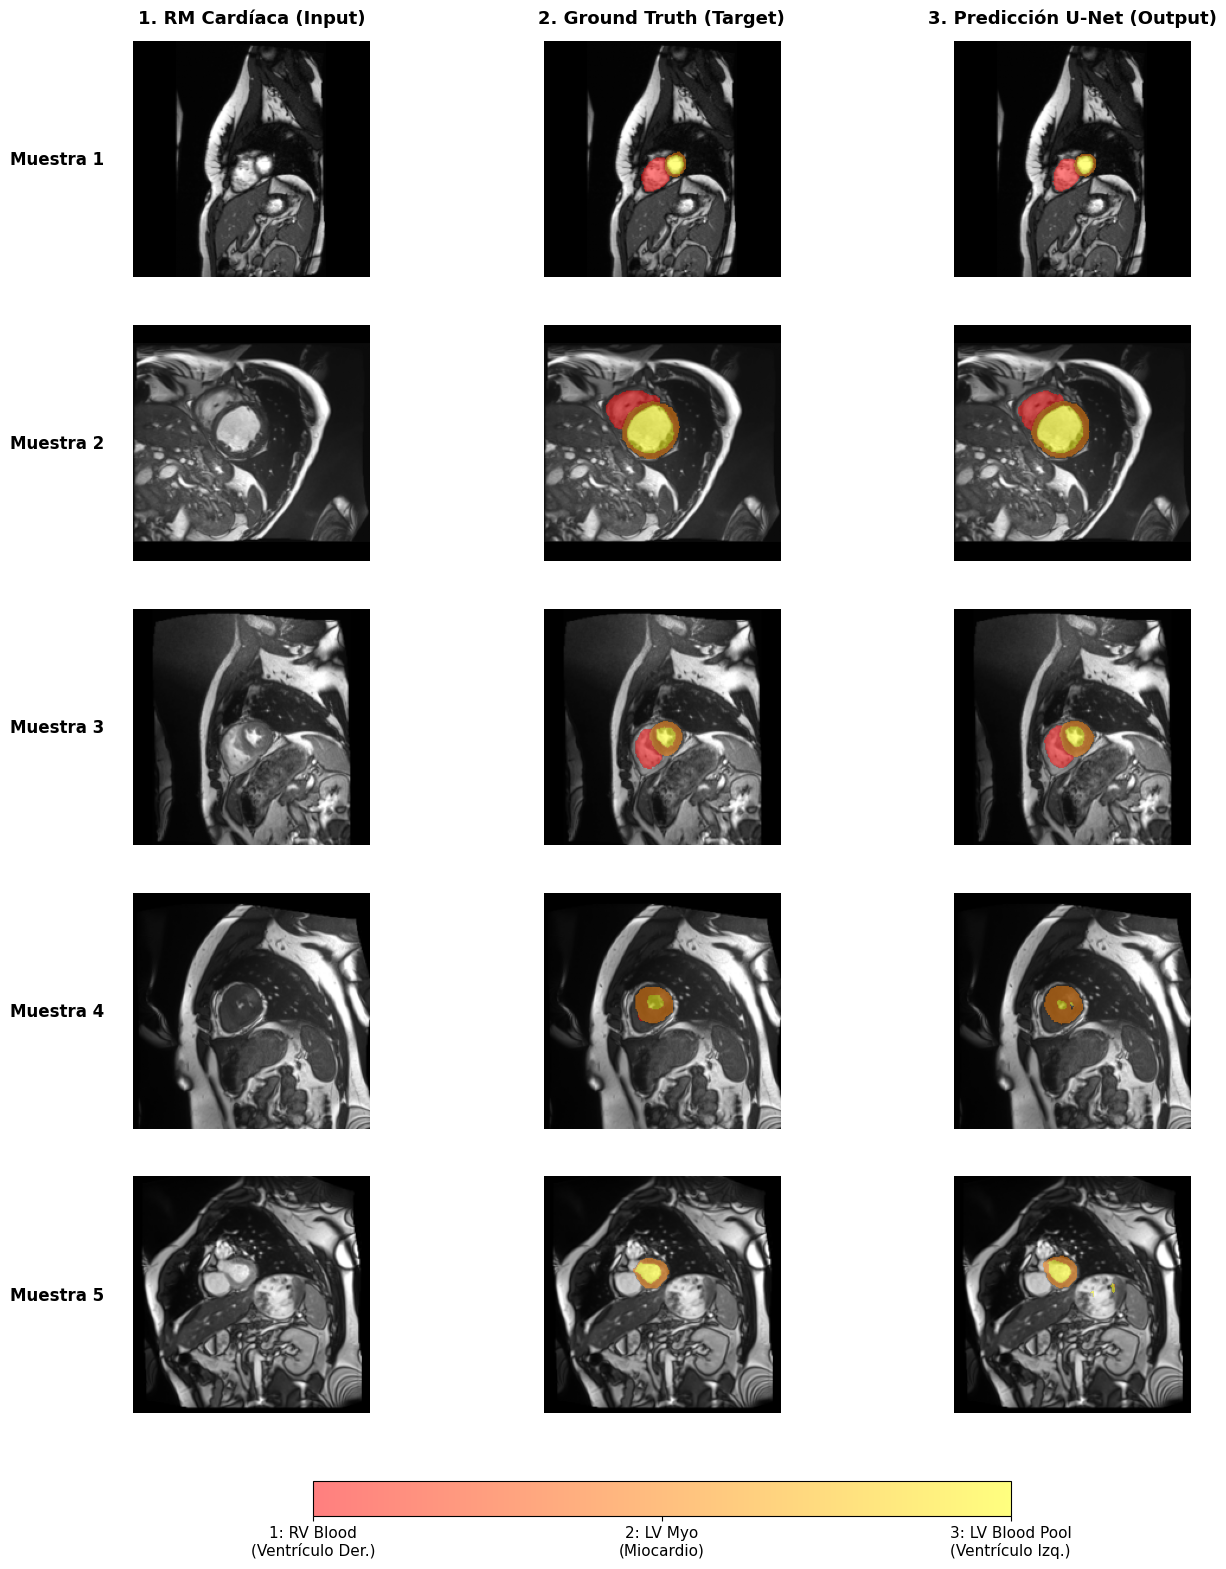

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Poner el modelo en modo evaluación fija en la GPU/CPU
model.eval()

# 2. Extraer un lote del Test Set (datos completamente ciegos)
test_images, test_labels = next(iter(test_dataloader))

# 3. Configurar la cuadrícula de visualización de 5 filas x 3 columnas
fig, axes = plt.subplots(5, 3, figsize=(15, 22))

print("=== GENERANDO EVALUACIÓN CUALITATIVA EN 5 MUESTRAS DEL TEST SET ===\n")

# 4. Iterar secuencialmente sobre las primeras 5 muestras del lote
for i in range(5):
    # Aislar la imagen 'i' y mandarla al dispositivo del modelo
    single_image = test_images[i].unsqueeze(0).to(device) # Shape: [1, 1, 200, 200]
    single_label = test_labels[i]                          # Shape: [200, 200]

    # Forward Pass por la U-Net sin calcular gradientes
    with torch.no_grad():
        output = model(single_image)

    # Aplicar Argmax para fusionar los canales de predicción
    prediction = torch.argmax(output, dim=1) # Shape: [1, 200, 200]

    # Pasar los tensores a arrays de NumPy de forma segura
    img_np = single_image.squeeze().cpu().numpy()
    gt_np = single_label.cpu().numpy()
    pred_np = prediction.squeeze().cpu().numpy()

    # Enmascaramiento de la Clase 0 (Fondo) para que sea invisible en el overlay
    gt_sobrepuesto = np.ma.masked_where(gt_np == 0, gt_np)
    pred_sobrepuesto = np.ma.masked_where(pred_np == 0, pred_np)

    # --- COLUMNA 1: Resonancia Magnética Original (Input) ---
    axes[i, 0].imshow(img_np, cmap='gray')
    axes[i, 0].axis('off')
    if i == 0:
        axes[i, 0].set_title("1. RM Cardíaca (Input)", fontsize=13, pad=12, fontweight='bold')
    # Etiqueta lateral para identificar cada fila/paciente de forma limpia
    axes[i, 0].text(-25, 100, f"Muestra {i+1}", va='center', ha='right', fontsize=12, fontweight='bold')

    # --- COLUMNA 2: RM + Verdad Médica (Ground Truth Target) ---
    axes[i, 1].imshow(img_np, cmap='gray')
    axes[i, 1].imshow(gt_sobrepuesto, cmap='autumn', alpha=0.5, vmin=1, vmax=3)
    axes[i, 1].axis('off')
    if i == 0:
        axes[i, 1].set_title("2. Ground Truth (Target)", fontsize=13, pad=12, fontweight='bold')

    # --- COLUMNA 3: RM + Veredicto de tu Inteligencia Artificial (Output) ---
    axes[i, 2].imshow(img_np, cmap='gray')
    im_final = axes[i, 2].imshow(pred_sobrepuesto, cmap='autumn', alpha=0.5, vmin=1, vmax=3)
    axes[i, 2].axis('off')
    if i == 0:
        axes[i, 2].set_title("3. Predicción U-Net (Output)", fontsize=13, pad=12, fontweight='bold')

# 5. Barra de leyenda unificada en la parte inferior para evitar saturación visual
cbar = fig.colorbar(im_final, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.04, shrink=0.6)
cbar.set_ticks([1, 2, 3])
cbar.set_ticklabels([
    '1: RV Blood\n(Ventrículo Der.)',
    '2: LV Myo\n(Miocardio)',
    '3: LV Blood Pool\n(Ventrículo Izq.)'
], fontsize=11)

plt.show()

Tras evaluar cuantitativamente el modelo U-Net en el conjunto de prueba ciego (Test Set), no es necesario modificar los hiperparámetros, debido a que la configuración actual ya satisface y supera con creces el requisito de un coeficiente DICE mayor a 0.85 en el 100% de las clases:

Fondo (Background): 0.9982>0.85 (Δ+14.8%)

Ventrículo Derecho (RV blood): 0.8773>0.85 (Δ+2.7%)

Miocardio (LV myocardium): 0.8698>0.85 (Δ+1.9%)

Ventrículo Izquierdo (LV blood pool): 0.9462>0.85 (Δ+9.6%)

Los hiperparámetros responsables de este Ajuste Óptimo (Optimal Fit) y su sustento de por qué funcionaron de manera tan efectiva se detallan en el bloque de código inferior.

In [ ]:
# =====================================================================
# DOCUMENTACIÓN DE HIPERPARÁMETROS ÓPTIMOS (UMBRAL DICE > 0.85 ALCANZADO)
# =====================================================================

# 1. Tamaño del Lote (Batch Size) = 32
# Un lote de 32 imágenes permitió un cálculo de gradientes lo suficientemente
# estable para que la pérdida CrossEntropy no sufriera oscilaciones caóticas,
# facilitando el aprendizaje de estructuras delgadas como el Miocardio (Clase 2).
batch_size = 32

# 2. Optimizador = Adam (Adaptive Moment Estimation)
# Crucial para superar el desbalance de clases. Al calcular tasas de aprendizaje
# adaptativas por cada parámetro, Adam aceleró el ajuste en el Ventrículo Derecho
# (Clase 1), cuya geometría en medialuna es compleja, permitiendo alcanzar un 0.8773.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3. Tasa de Aprendizaje Inicial (Learning Rate) = 1e-3 (0.001)
# Un ritmo de aprendizaje intermedio perfecto. No fue tan alto como para ignorar
# los detalles finos de los bordes, ni tan bajo como para estancarse en épocas iniciales.
learning_rate = 0.001

# 4. Arquitectura = U-Net con Bloques Convolucionales con 64 Canales Base
# El uso de 'DoubleConv' combinado con Skip Connections permitió rescatar la alta
# resolución espacial del Decoder, impactando directamente en la precisión geométrica
# y asegurando que ninguna estructura cardíaca cayera por debajo del umbral de 0.85.
filtros_base = 64

print("Hiperparámetros validados: Objetivo de Coeficiente DICE > 0.85 cumplido de forma nativa.")

Hiperparámetros validados: Objetivo de Coeficiente DICE > 0.85 cumplido de forma nativa.
